In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import glob
from time import time
import os
from dataclasses import replace
from RaTag.core.datatypes import Run, SetPmt, S2Areas
from RaTag.core.config import TimingConfig, IntegrationConfig, FitConfig
from RaTag.core.wfm2read_fast import wfm2read
from RaTag.io.bootstrap import bootstrap_from_config
from RaTag.alphas.alphas_workflow import map_alpha_events
from RaTag.thgem_tpc.drift_workflow import map_drift_physics
from RaTag.thgem_tpc.timing_workflow import map_time_windows, resolve_set_timing, map_timing_plots
from RaTag.thgem_tpc.recoil_workflow import map_recoil_integration, map_recoil_fits, map_recoil_plots
from RaTag.thgem_tpc.coincidence_workflow import map_coincidence_extraction
from RaTag.thgem_tpc.multiiso_workflow import map_multiiso_separation, map_multiiso_s2_vs_field
from RaTag.io import file_ops
from RaTag.plotting import plot_s2areas_summary

%matplotlib inline

# Initialize test run and drift properties

In [3]:
config_path = '/Users/pabloherrero/sabat/RaTagging/configs/recoils/run43_analysis.yaml'

run = bootstrap_from_config(config_path)

Found 9 directories in RUN43_EL25kVcm
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0120_Anode1120 with 200 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0188_Anode1188 with 200 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0288_Anode1288 with 200 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0480_Anode1480 with 200 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0576_Anode1576 with 200 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0672_Anode1672 with 200 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0768_Anode1768 with 200 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0864_Anode1864 with 200 waveforms.
  🔹 Bootstrapping Alpha Set from: FieldScan_Gate0960_Anode1960 with 200 waveforms.
  → Bootstrapped 9 PMT Sets and 9 Alpha Sets. (Multi-Isotope: True)


In [4]:
run = map_drift_physics(run, force=False)

  📂 Cache Hit: Loaded metadata for 'drift_field in FieldScan_Gate0120_Anode1120'
  📂 Cache Hit: Loaded metadata for 'red_EL_field in FieldScan_Gate0120_Anode1120'
  📂 Cache Hit: Loaded metadata for 'time_drift in FieldScan_Gate0120_Anode1120'
  📂 Cache Hit: Loaded metadata for 'drift_field in FieldScan_Gate0188_Anode1188'
  📂 Cache Hit: Loaded metadata for 'red_EL_field in FieldScan_Gate0188_Anode1188'
  📂 Cache Hit: Loaded metadata for 'time_drift in FieldScan_Gate0188_Anode1188'
  📂 Cache Hit: Loaded metadata for 'drift_field in FieldScan_Gate0288_Anode1288'
  📂 Cache Hit: Loaded metadata for 'red_EL_field in FieldScan_Gate0288_Anode1288'
  📂 Cache Hit: Loaded metadata for 'time_drift in FieldScan_Gate0288_Anode1288'
  📂 Cache Hit: Loaded metadata for 'drift_field in FieldScan_Gate0480_Anode1480'
  📂 Cache Hit: Loaded metadata for 'red_EL_field in FieldScan_Gate0480_Anode1480'
  📂 Cache Hit: Loaded metadata for 'time_drift in FieldScan_Gate0480_Anode1480'
  📂 Cache Hit: Loaded metada

In [5]:
run = map_alpha_events(run, force=False)


RECONSTRUCTING ALPHA ENERGIES: RUN_43
Force flag: False
  📂 Cache Hit: Loaded metadata for 'n_alpha_energies in FieldScan_Gate0120_Anode1120'
  📂 Cache Hit: Loaded metadata for 'n_alpha_energies in FieldScan_Gate0188_Anode1188'
  📂 Cache Hit: Loaded metadata for 'n_alpha_energies in FieldScan_Gate0288_Anode1288'
  📂 Cache Hit: Loaded metadata for 'n_alpha_energies in FieldScan_Gate0480_Anode1480'
  📂 Cache Hit: Loaded metadata for 'n_alpha_energies in FieldScan_Gate0576_Anode1576'
  📂 Cache Hit: Loaded metadata for 'n_alpha_energies in FieldScan_Gate0672_Anode1672'
  📂 Cache Hit: Loaded metadata for 'n_alpha_energies in FieldScan_Gate0768_Anode1768'
  📂 Cache Hit: Loaded metadata for 'n_alpha_energies in FieldScan_Gate0864_Anode1864'
  📂 Cache Hit: Loaded metadata for 'n_alpha_energies in FieldScan_Gate0960_Anode1960'


In [6]:
run = map_recoil_integration(run, force=False)


INTEGRATING S2 RECOILS: RUN_43
  📂 Cache Hit: Loaded metadata for 'n_areas_recoil in FieldScan_Gate0120_Anode1120'
  📂 Cache Hit: Loaded metadata for 'n_areas_recoil in FieldScan_Gate0188_Anode1188'
  📂 Cache Hit: Loaded metadata for 'n_areas_recoil in FieldScan_Gate0288_Anode1288'
  📂 Cache Hit: Loaded metadata for 'n_areas_recoil in FieldScan_Gate0480_Anode1480'
  📂 Cache Hit: Loaded metadata for 'n_areas_recoil in FieldScan_Gate0576_Anode1576'
  📂 Cache Hit: Loaded metadata for 'n_areas_recoil in FieldScan_Gate0672_Anode1672'
  📂 Cache Hit: Loaded metadata for 'n_areas_recoil in FieldScan_Gate0768_Anode1768'
  📂 Cache Hit: Loaded metadata for 'n_areas_recoil in FieldScan_Gate0864_Anode1864'
  📂 Cache Hit: Loaded metadata for 'n_areas_recoil in FieldScan_Gate0960_Anode1960'


In [7]:
runm = map_multiiso_separation(run, force=True)


SEPARATING MULTI-ISOTOPE SETS: RUN_43

  Mapping FieldScan_Gate0120_Anode1120...
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/s2_areas/FieldScan_Gate0120_Anode1120_s2_areas.npz
  Loading alpha_energies arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/alpha_energies/FieldScan_Gate0120_Anode1120_alpha_energies.npz
    ✓ Separated Th228: 8419 events
    ✓ Separated Ra224: 5442 events
    ✓ Separated Po216: 2550 events
    ✓ Separated Po212: 3592 events

  Mapping FieldScan_Gate0188_Anode1188...
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/s2_areas/FieldScan_Gate0188_Anode1188_s2_areas.npz
  Loading alpha_energies arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/alpha_energies/FieldScan_Gate0188_Anode1188_alpha_energies.npz
    ✓ Separated Th228: 9972 events
    ✓ Separated Ra224: 6612 events
    ✓ Separated Po216: 2998 events
    ✓ Separated Po212: 3791 events

  Mapping 

In [10]:
for iso, iso_run in runm.items():
    fitted_run = map_recoil_fits(iso_run, force=True)
    runm[iso] = fitted_run  # Update the dict with the fitted run
    plotted_run = map_recoil_plots(fitted_run, force=True)


FITTING S2 AREA DISTRIBUTIONS: RUN_43_Th228
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/isotope_areas/Th228/FieldScan_Gate0120_Anode1120_Th228_s2_areas.npz
Histogramming with bin_cuts: (0, 50)
  Fit success: True, χ²/DOF: 122.93
  ✓ Fit: μ=14.311 ± 0.283 mV·µs
  ✓ FieldScan_Gate0120_Anode1120_Th228: Computed 'area_s2_fit_success' and stored metadata
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/isotope_areas/Th228/FieldScan_Gate0188_Anode1188_Th228_s2_areas.npz
Histogramming with bin_cuts: (0, 50)
  Fit success: True, χ²/DOF: 46.53
  ✓ Fit: μ=14.374 ± 0.305 mV·µs
  ✓ FieldScan_Gate0188_Anode1188_Th228: Computed 'area_s2_fit_success' and stored metadata
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/isotope_areas/Th228/FieldScan_Gate0288_Anode1288_Th228_s2_areas.npz
Histogramming with bin_cuts: (0, 50)
  Fit success: True, χ²/DOF: 54.44
  ✓ Fit: μ=16.258 ± 0.306 mV·µ

/Users/pabloherrero/sabat/RaTagging/RaTag/el_tpc/fit_s2_area.py:20: RuntimeWarning: divide by zero encountered in divide
  tail = A_tail / (denom_safe)**m


  ✓ FieldScan_Gate0288_Anode1288_Th228: Computed 'area_s2_fit_success' and stored metadata
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/isotope_areas/Th228/FieldScan_Gate0480_Anode1480_Th228_s2_areas.npz
Histogramming with bin_cuts: (0, 50)
  Fit success: True, χ²/DOF: 132.74
  ✓ Fit: μ=19.182 ± 0.334 mV·µs
  ✓ FieldScan_Gate0480_Anode1480_Th228: Computed 'area_s2_fit_success' and stored metadata
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/isotope_areas/Th228/FieldScan_Gate0576_Anode1576_Th228_s2_areas.npz
Histogramming with bin_cuts: (0, 50)
  Fit success: True, χ²/DOF: 99.21
  ✓ Fit: μ=20.490 ± 0.317 mV·µs
  ✓ FieldScan_Gate0576_Anode1576_Th228: Computed 'area_s2_fit_success' and stored metadata
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/isotope_areas/Th228/FieldScan_Gate0672_Anode1672_Th228_s2_areas.npz
Histogramming with bin_cuts: (0, 50)
  Fit success: True

/Users/pabloherrero/sabat/RaTagging/RaTag/el_tpc/fit_s2_area.py:20: RuntimeWarning: divide by zero encountered in divide
  tail = A_tail / (denom_safe)**m
/Users/pabloherrero/sabat/RaTagging/RaTag/el_tpc/fit_s2_area.py:20: RuntimeWarning: overflow encountered in divide
  tail = A_tail / (denom_safe)**m


  Loaded fit model for FieldScan_Gate0960_Anode1960 with lower_bound=0.0
  → Saved: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/plots/s2_areas/Th228/RUN_43_Th228_histograms.png
  → Saved: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/plots/s2_areas/Th228/RUN_43_Th228_s2_vs_field.png

FITTING S2 AREA DISTRIBUTIONS: RUN_43_Ra224
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/isotope_areas/Ra224/FieldScan_Gate0120_Anode1120_Ra224_s2_areas.npz
Histogramming with bin_cuts: (0, 50)
  Fit success: True, χ²/DOF: 44.14
  ✓ Fit: μ=14.446 ± 0.342 mV·µs
  ✓ FieldScan_Gate0120_Anode1120_Ra224: Computed 'area_s2_fit_success' and stored metadata
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/isotope_areas/Ra224/FieldScan_Gate0188_Anode1188_Ra224_s2_areas.npz
Histogramming with bin_cuts: (0, 50)
  Fit success: True, χ²/DOF: 51.19
  ✓ Fit: μ=15.027 ± 0.283 mV·µs
  ✓ FieldScan_Gate0188_Anode1188_Ra224: Comput

...

Histogramming with bin_cuts: (0, 50)
  Fit success: True, χ²/DOF: 256.39
  ✓ Fit: μ=19.024 ± 0.283 mV·µs
  ✓ FieldScan_Gate0768_Anode1768_Po212: Computed 'area_s2_fit_success' and stored metadata
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/isotope_areas/Po212/FieldScan_Gate0864_Anode1864_Po212_s2_areas.npz
Histogramming with bin_cuts: (0, 50)
  Fit success: True, χ²/DOF: 253.91
  ✓ Fit: μ=17.842 ± 0.283 mV·µs
  ✓ FieldScan_Gate0864_Anode1864_Po212: Computed 'area_s2_fit_success' and stored metadata
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/isotope_areas/Po212/FieldScan_Gate0960_Anode1960_Po212_s2_areas.npz
Histogramming with bin_cuts: (0, 50)
  Fit success: True, χ²/DOF: 277.00
  ✓ Fit: μ=18.084 ± 0.283 mV·µs


/Users/pabloherrero/sabat/RaTagging/RaTag/el_tpc/fit_s2_area.py:20: RuntimeWarning: divide by zero encountered in divide
  tail = A_tail / (denom_safe)**m
/Users/pabloherrero/sabat/RaTagging/RaTag/el_tpc/fit_s2_area.py:20: RuntimeWarning: divide by zero encountered in divide
  tail = A_tail / (denom_safe)**m


  ✓ FieldScan_Gate0960_Anode1960_Po212: Computed 'area_s2_fit_success' and stored metadata

GENERATING RECOIL S2 AREAS QA PLOTS: RUN_43_Po212
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/isotope_areas/Po212/FieldScan_Gate0120_Anode1120_Po212_s2_areas.npz
  Loaded fit model for FieldScan_Gate0120_Anode1120 with lower_bound=0.0
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/isotope_areas/Po212/FieldScan_Gate0188_Anode1188_Po212_s2_areas.npz
  Loaded fit model for FieldScan_Gate0188_Anode1188 with lower_bound=0.0
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/isotope_areas/Po212/FieldScan_Gate0288_Anode1288_Po212_s2_areas.npz
  Loaded fit model for FieldScan_Gate0288_Anode1288 with lower_bound=0.0
  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/isotope_areas/Po212/FieldScan_Gate0480_Anode1480_Po212_s2_areas.npz
  Loaded fit model for 

/Users/pabloherrero/sabat/RaTagging/RaTag/el_tpc/fit_s2_area.py:20: RuntimeWarning: overflow encountered in divide
  tail = A_tail / (denom_safe)**m


  → Saved: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/plots/s2_areas/Po212/RUN_43_Po212_histograms.png
  → Saved: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/plots/s2_areas/Po212/RUN_43_Po212_s2_vs_field.png


In [9]:
run = map_multiiso_s2_vs_field(run, spawned_runs=runm, force=True)


PLOTTING MULTI-ISOTOPE S2 VS FIELD: RUN_43
  → Saved: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/plots/s2_areas/multi/RUN_43_s2_vs_field_multiiso.png


In [29]:
setPo0 = runm['Po212'].sets[0]
setPo0.area_s2_mean

16.73337616035107

In [11]:
runm['Ra224'].sets[6].area_s2_mean

22.01064691065145

In [12]:
runm['Po212'].sets[6].area_s2_mean

19.024028642499232

In [30]:
pathfitPo0 = '/Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/fits/Po212/FieldScan_Gate0120_Anode1120_Po212_s2_areas_hist_fit.json'
fitpo0 = file_ops.load_fit_result(pathfitPo0)
fitpo0

/Users/pabloherrero/sabat/RaTagging/RaTag/el_tpc/fit_s2_area.py:20: RuntimeWarning: divide by zero encountered in divide
  tail = A_tail / (denom_safe)**m


  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN43_EL25kVcm/isotope_areas/Po212/FieldScan_Gate0120_Anode1120_Po212_s2_areas.npz


/Users/pabloherrero/sabat/RaTagging/RaTag/el_tpc/fit_s2_area.py:20: RuntimeWarning: divide by zero encountered in divide
  tail = A_tail / (denom_safe)**m


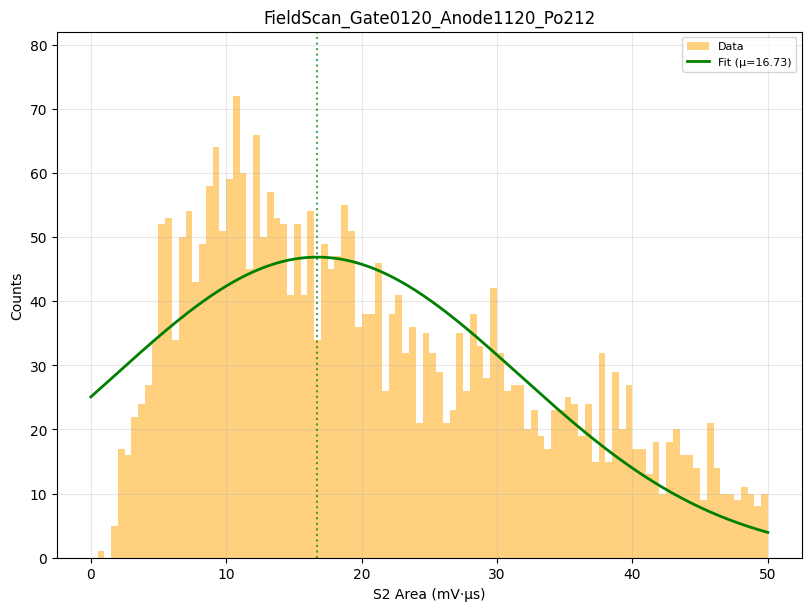

In [36]:
s2_areas = file_ops.load_s2areas(setPo0)
fig, ax = plt.subplots(figsize=(8, 6), layout='constrained')
plot_s2areas_summary(ax, set_name=setPo0.name, s2_areas=s2_areas, fit_model=fitpo0, bin_cuts=(0, 50), )

In [27]:
fitpo0.params['sig_x0'].value

16.73337616035107

In [25]:
set6 = run.sets[6]
s2_areas = load_s2areas(set6)

  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN35_EL20kVcm/s2_areas/FieldScan_Gate0480_Anode1280_s2_areas.npz


In [27]:
s2_areas

S2Areas(uids=array([  65,   68,   69, ..., 2253, 2259, 2262]), areas=array([1.29925449, 0.98648967, 2.22679696, ..., 1.4565153 , 0.92353287,
       2.8724546 ]))

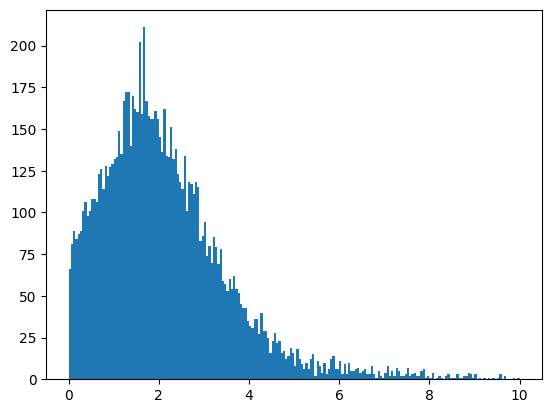

In [34]:
plt.hist(s2_areas.areas, bins=200, range=(0, 10));

# Check first set results

In [24]:
from RaTag.io.file_ops import load_s2areas, load_s2areas_from_path, load_npz_arrays
set0 = run.alpha_sets[0]

In [21]:
runm.sets[0]

SetPmt state:
  source_dir = /Volumes/KINGSTON/RaTag_data/raw_waveforms/RUN34_EL15k/FieldScan_Gate0120_Anode0720
  filenames = <50 files, 47200 waveforms, FastFrame(944 frames/file)>
  multiiso = True
  target_isotope = Th228
  ff = True
  nframes = 944
  gate = 120
  anode = 720
  drift_field = 250.0
  EL_field = 15000.0
  red_drift_field = 1.025
  red_EL_field = 61.508
  speed_drift = 1.329
  time_drift = 3.611
  t_s1 = -4.781
  t_s1_std = 0.653
  t_s2_start = -0.81
  t_s2_start_std = 1.708
  t_s2_end = 4.961
  t_s2_end_std = 2.743
  n_areas_recoil = 49350
  area_s2_mean = 3.125
  area_s2_sigma = 0.307
  area_s2_ci95 = 0.064
  area_s2_fit_success = True
  s2_background_bound = 2.85

  Missing:
    sampling_rate, diffusion_coefficient, baseline_median, baseline_std, filtered_drift_time

In [9]:
load_s2areas_from_path('/Volumes/KINGSTON/RaTag_data/processed/RUN34_EL15k/s2_areas/FieldScan_Gate0120_Anode0720_s2_areas.npz')

S2Areas(uids=array([1296685184, 1296685185, 1296685186, ..., 1296686168, 1296686169,
       1296686170]), areas=array([0.64864804, 4.15286601, 0.05776656, ..., 0.01575344, 0.080996  ,
       0.        ]))

In [18]:
path = '/Volumes/KINGSTON/RaTag_data/processed/RUN34_EL15k/alpha_energies/FieldScan_Gate0120_Anode0720_alpha_energies.npz'
alpha_data = load_npz_arrays(set0, 'alpha_energies')
len(alpha_data['uids'])

  Loading alpha_energies arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN34_EL15k/alpha_energies/FieldScan_Gate0120_Anode0720_alpha_energies.npz


49350

In [ ]:
s2_areas = load_s2areas(set0)
s2_areas.uids

# plt.hist(s2_areas.areas, bins=100, range=(0.5, 7));

  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN34_EL15k/s2_areas/FieldScan_Gate0768_Anode1368_s2_areas.npz


array([1296685312, 1296685313, 1296685314, ..., 1296686296, 1296686297,
       1296686298])

In [27]:
set_pmt = run.sets[0]
set_alpha = run.alpha_sets[0]
set_pmt.name, set_alpha.name

('FieldScan_Gate0120_Anode0720', 'FieldScan_Gate0120_Anode0720')

In [39]:
pmt_arrays = load_npz_arrays(set_pmt, 's2_areas')
alpha_arrays = load_npz_arrays(set_alpha, 'alpha_energies')

# 2. Safely merge on UIDs
df_pmt = pd.DataFrame(pmt_arrays).drop_duplicates(subset=['uids'])
df_alpha = pd.DataFrame(alpha_arrays).drop_duplicates(subset=['uids'])
df_merged = pd.merge(df_pmt, df_alpha, on='uids', how='inner')

spawned_data = []
for isotope, (e_min, e_max) in set_alpha.isotope_ranges_V.items():
    mask = (df_merged['energies'] >= e_min) & (df_merged['energies'] <= e_max)
    df_iso = df_merged[mask]

  Loading s2_areas arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN34_EL15k/s2_areas/FieldScan_Gate0120_Anode0720_s2_areas.npz
  Loading alpha_energies arrays from: /Volumes/KINGSTON/RaTag_data/processed/RUN34_EL15k/alpha_energies/FieldScan_Gate0120_Anode0720_alpha_energies.npz


In [37]:
# pmt_arrays, alpha_arrays
set_alpha.isotope_ranges_E

{'Th228': [5.325, 5.478],
 'Ra224': [5.647, 5.796],
 'Bi212': [6.088, 6.288],
 'Rn220': [6.351, 6.47],
 'Po216': [6.851, 6.962],
 'Po212': [8.709, 8.862]}

In [40]:
df_iso

,s2_areas,uids,energies
39,0.174782,1296685223,7.180863
42,2.355768,1296685226,7.127037
102,0.273628,1296685286,7.127354
106,1.670295,1296685290,7.120952
130,0.804505,1296685314,7.100596
162,1.386168,1296685346,7.093745
213,0.483556,1296685397,7.079062
226,0.499997,1296685410,7.114605
290,0.267439,1296685474,7.114424
327,1.944675,1296685511,7.156212
